# Paper figures

Single, top-to-bottom notebook that regenerates every figure cited in the
paper from the **checked-in artifacts** under `reports/` — no NSGA-II,
surrogate training, or LHS regeneration runs here, so it executes in well
under a minute on a laptop.

Inputs (all committed to the repo):

- `reports/pareto_fronts/front_<scenario>.csv` — evaluator-truth Pareto
  fronts (regenerate with `make pareto-fronts`).
- `reports/rediscovery_loo_evaluator/` — leave-one-out rediscovery sweep
  (regenerate with `python scripts/run_rediscovery_loo.py --all`).
- `roverdevkit.validation.rover_comparison.compare_all()` — flown-rover
  validation against published mission data (also a CI gate).

Outputs are written as 200-DPI PNGs to `reports/figures/`.

> Schema v9: scientific payload is an explicit mission requirement, and the
> canonical fronts + rediscovery sweep share the fixed-tilt panel
> approximation (`panel_tilt_deg = min(80, |lat|)`). See
> `reports/phase3_design_rules.md` and `reports/rediscovery_loo_comparison.md`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from roverdevkit.tradespace.visualize import set_paper_rcparams

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARETO_DIR = REPO / "reports" / "pareto_fronts"
REDISC_DIR = REPO / "reports" / "rediscovery_loo_evaluator"
FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

set_paper_rcparams()

# Canonical scenario -> human label, in paper order.
SCENARIOS = {
    "equatorial_mare_traverse": "Mare traverse",
    "polar_prospecting": "Polar prospecting",
    "highland_slope_capability": "Highland slope",
    "crater_rim_survey": "Crater rim survey",
}
print("repo root:", REPO)
print("figures ->", FIG_DIR)

repo root: /Users/jonreifschneider/Duke/Research/AMSL/roverdevkit
figures -> /Users/jonreifschneider/Duke/Research/AMSL/roverdevkit/reports/figures


## Figure 1 — Pareto fronts across the four mission scenarios

Range vs total mass for each canonical scenario, coloured by slope
capability. Every point is corrected-evaluator truth (BW + wheel-level SCM
correction), not a surrogate prediction.

wrote /Users/jonreifschneider/Duke/Research/AMSL/roverdevkit/reports/figures/fig_pareto_fronts.png


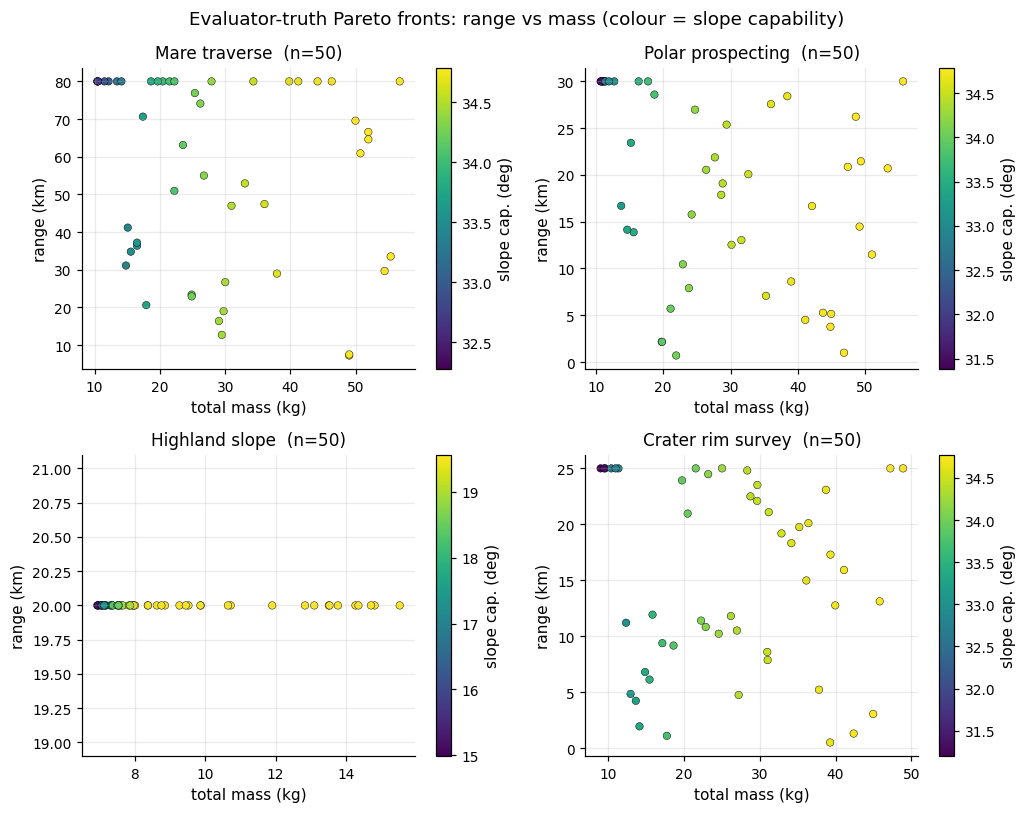

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.5))
for ax, (slug, title) in zip(axes.ravel(), SCENARIOS.items()):
    df = pd.read_csv(PARETO_DIR / f"front_{slug}.csv")
    sc = ax.scatter(
        df["total_mass_kg"],
        df["range_km"],
        c=df["slope_capability_deg"],
        cmap="viridis",
        s=24,
        edgecolor="k",
        linewidth=0.3,
    )
    ax.set_title(f"{title}  (n={len(df)})")
    ax.set_xlabel("total mass (kg)")
    ax.set_ylabel("range (km)")
    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("slope cap. (deg)")
fig.suptitle("Evaluator-truth Pareto fronts: range vs mass (colour = slope capability)")
fig.tight_layout()
out = FIG_DIR / "fig_pareto_fronts.png"
fig.savefig(out)
print("wrote", out)
plt.show()

## Figure 2 — Rediscovery: real rovers vs the optimiser

**2a.** Normalised design-space distance from each real rover to the nearest
Pareto design under its class-generic micro-rover scenario. The dashed line is
the expected L2 between two uniform points in the 9-D unit cube (≈1.22); bars
well below it mean the optimiser lands near the published design. Green bars
are inside the 0.4 "rediscovery" band.

wrote /Users/jonreifschneider/Duke/Research/AMSL/roverdevkit/reports/figures/fig_rediscovery_distance.png


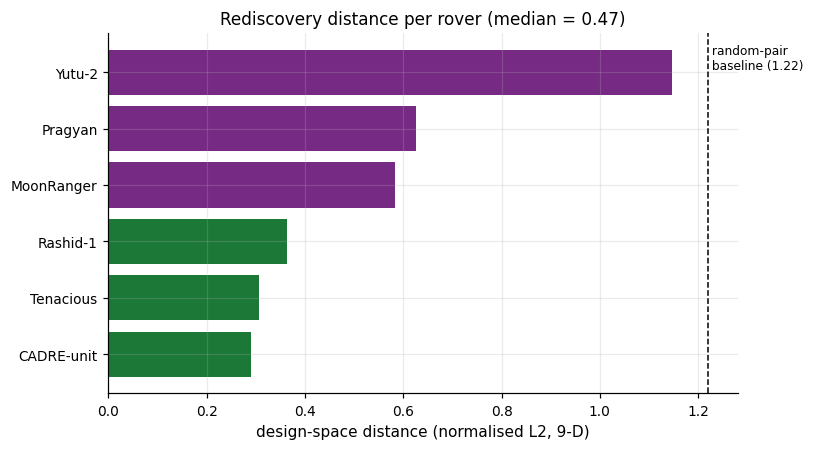

In [3]:
RANDOM_PAIR_BASELINE = 1.22  # expected L2 between two uniform points, 9-D unit cube

redisc = pd.read_csv(REDISC_DIR / "summary.csv").sort_values("design_space_distance")
colors = ["#1b7837" if d < 0.4 else "#762a83" for d in redisc["design_space_distance"]]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(redisc["rover_name"], redisc["design_space_distance"], color=colors)
ax.axvline(RANDOM_PAIR_BASELINE, ls="--", color="k", lw=1)
ax.text(RANDOM_PAIR_BASELINE, len(redisc) - 0.5, " random-pair\n baseline (1.22)", va="top", fontsize=8)
median = redisc["design_space_distance"].median()
ax.set_xlabel("design-space distance (normalised L2, 9-D)")
ax.set_title(f"Rediscovery distance per rover (median = {median:.2f})")
fig.tight_layout()
out = FIG_DIR / "fig_rediscovery_distance.png"
fig.savefig(out)
print("wrote", out)
plt.show()

**2b.** Mass–range overlay for the two flown rovers: the optimiser's Pareto
front (grey), the nearest design the optimiser found (green), and the real
rover evaluated under the same class-generic scenario (red star).

wrote /Users/jonreifschneider/Duke/Research/AMSL/roverdevkit/reports/figures/fig_rediscovery_overlay.png


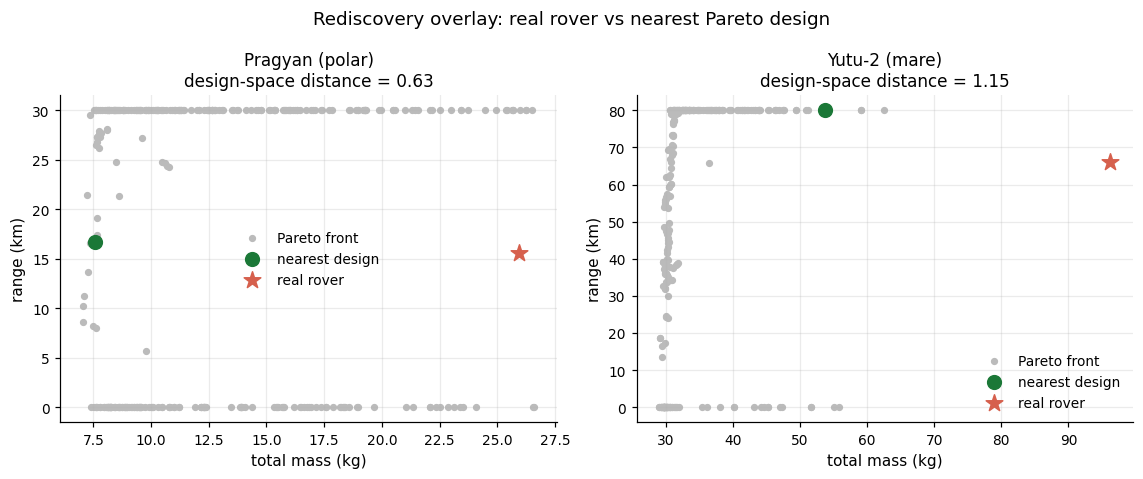

In [4]:
flown = {"pragyan": "Pragyan (polar)", "yutu_2": "Yutu-2 (mare)"}

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
for ax, (slug, label) in zip(axes, flown.items()):
    d = json.loads((REDISC_DIR / f"{slug}.json").read_text())
    front = d["pareto_front"]
    mass = [p["metrics"]["total_mass_kg"] for p in front]
    rng = [p["metrics"]["range_km"] for p in front]
    ax.scatter(mass, rng, s=14, color="#bbbbbb", label="Pareto front")
    nm = d["nearest_pareto_metrics"]
    rm = d["rover_metrics_under_generic_scenario"]
    ax.scatter([nm["total_mass_kg"]], [nm["range_km"]], color="#1b7837", s=80, marker="o", zorder=5, label="nearest design")
    ax.scatter([rm["total_mass_kg"]], [rm["range_km"]], color="#d6604d", s=130, marker="*", zorder=6, label="real rover")
    ax.set_title(f"{label}\ndesign-space distance = {d['design_space_distance']:.2f}")
    ax.set_xlabel("total mass (kg)")
    ax.set_ylabel("range (km)")
    ax.legend(loc="best")
fig.suptitle("Rediscovery overlay: real rover vs nearest Pareto design")
fig.tight_layout()
out = FIG_DIR / "fig_rediscovery_overlay.png"
fig.savefig(out)
print("wrote", out)
plt.show()

## Figure 3 — Flown-rover validation

Evaluator-predicted peak solar power against the digitised published band for
each flown rover. The same `compare_all()` summary printed below is enforced
as a CI gate in `tests/test_rover_comparison.py`.

Rover      range_pred   range_pub  range_ratio  peak_solar_pred  peak_solar_pub  thermal  motor  PASS?
---------------------------------------------------------------------------------------------------------
Pragyan         500 m       101 m       4.93x          44.8 W          50.0 W  match   ok     PASS
Yutu-2          200 m        25 m       8.00x         136.4 W         135.0 W  match   ok     PASS
---------------------------------------------------------------------------------------------------------
Pass rate: 2/2
wrote /Users/jonreifschneider/Duke/Research/AMSL/roverdevkit/reports/figures/fig_validation_peak_solar.png


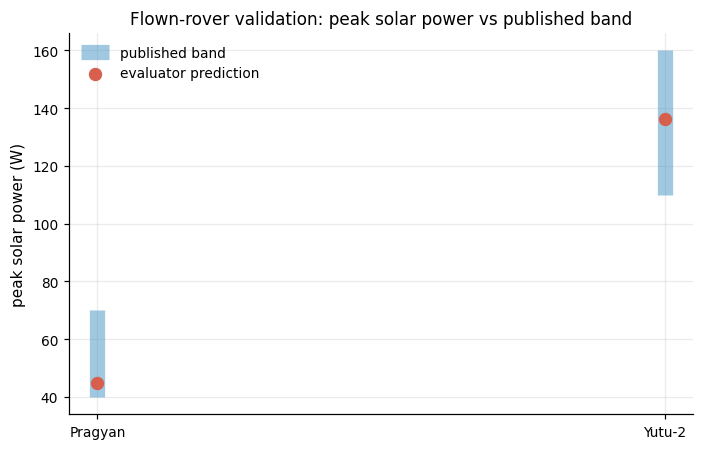

In [5]:
from roverdevkit.validation.rover_comparison import compare_all, format_report

comparison = compare_all()
print(format_report(comparison))

names = [r.rover_name for r in comparison.results]
pred = [r.peak_solar_power_w_predicted for r in comparison.results]
low = [r.truth.peak_solar_power_w_low for r in comparison.results]
high = [r.truth.peak_solar_power_w_high for r in comparison.results]
x = list(range(len(names)))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for i in x:
    ax.plot([i, i], [low[i], high[i]], color="#4393c3", lw=10, alpha=0.5, solid_capstyle="butt", label="published band" if i == 0 else None)
ax.scatter(x, pred, color="#d6604d", zorder=5, s=60, label="evaluator prediction")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("peak solar power (W)")
ax.set_title("Flown-rover validation: peak solar power vs published band")
ax.legend()
fig.tight_layout()
out = FIG_DIR / "fig_validation_peak_solar.png"
fig.savefig(out)
print("wrote", out)
plt.show()

## Artifacts written

All figures land in `reports/figures/`. Re-run the upstream artifact
generators (`make pareto-fronts`, `scripts/run_rediscovery_loo.py`) and then
re-run this notebook top-to-bottom to refresh every figure.

In [6]:
for p in sorted(FIG_DIR.glob("*.png")):
    print(p.relative_to(REPO), f"({p.stat().st_size // 1024} KB)")

reports/figures/fig_pareto_fronts.png (220 KB)
reports/figures/fig_rediscovery_distance.png (51 KB)
reports/figures/fig_rediscovery_overlay.png (107 KB)
reports/figures/fig_validation_peak_solar.png (45 KB)
